In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import math
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB
from scipy import integrate
#import h5py
#import plotly.express as px

In [2]:
import numpy as np

def generate_filled_sphere(radius, d):
    """
    Generate 3D coordinates filling a sphere of given radius with uniform spacing `d`.
    
    :param radius: Radius of the sphere
    :param d: Spacing between adjacent points
    :return: A NumPy array of shape (N, 3) containing 3D coordinates
    """
    points_list = []
    
    # Generate radial layers
    num_r = int(radius / d) + 1
    r_values = np.linspace(0, radius, num_r)

    for r in r_values:
        if r == 0:
            points_list.append([[0, 0, 0]])  # Center point
            continue
        
        # Compute number of points for angular distribution at this radius
        num_theta = max(1, int(2 * np.pi * r / d))  # Around the circle
        num_phi = max(1, int(np.pi * r / d))  # Along vertical
        
        theta_values = np.linspace(0, 2 * np.pi, num_theta, endpoint=False)  # Azimuthal angle
        phi_values = np.linspace(0, np.pi, num_phi)  # Polar angle
        
        # Create meshgrid
        Theta, Phi = np.meshgrid(theta_values, phi_values, indexing='ij')

        # Convert to Cartesian coordinates
        X = r * np.sin(Phi) * np.cos(Theta)
        Y = r * np.sin(Phi) * np.sin(Theta)
        Z = r * np.cos(Phi)

        # Store points
        points = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))
        points_list.append(points)

    # Combine all points into a single array
    all_points = np.vstack(points_list)
    
    return all_points


def generate_filled_cylinder_with_spacing(radius, height, d):
    """
    Generate 3D coordinates of points filling a cylindrical volume with a given spacing `d`.
    
    :param radius: Radius of the cylinder
    :param height: Height of the cylinder
    :param d: Spacing between adjacent points
    :return: A NumPy array of shape (N, 3) containing 3D coordinates
    """
    # Compute number of layers based on spacing `d`
    num_height = int(height / d) + 1  # Number of height levels
    num_inner = int(radius / d) + 1   # Number of radial layers

    # Generate radial distances ensuring spacing `d`
    r = np.linspace(0, radius, num_inner)

    # Compute angular divisions dynamically per radial layer
    points_list = []
    
    for ri in r:
        if ri == 0:
            theta = np.array([0])  # Only one point at the center
        else:
            num_radial = max(1, int(2 * np.pi * ri / d))  # Circumference-based division
            theta = np.linspace(0, 2 * np.pi, num_radial, endpoint=False)

        z = np.linspace(0, height, num_height)  # Evenly spaced heights

        # Create meshgrid
        Theta, Z = np.meshgrid(theta, z, indexing='ij')

        # Convert to Cartesian coordinates
        X = ri * np.cos(Theta)
        Y = ri * np.sin(Theta)

        # Stack into a list
        points = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))
        points_list.append(points)

    # Combine all points into a single array
    all_points = np.vstack(points_list)
    
    return all_points

def invariant(data):
    '''Calculates the invariant'''
    q = data[:,0]
    I = data[:,1]
    invariant = integrate.simpson(q**2*I, q)
    return invariant



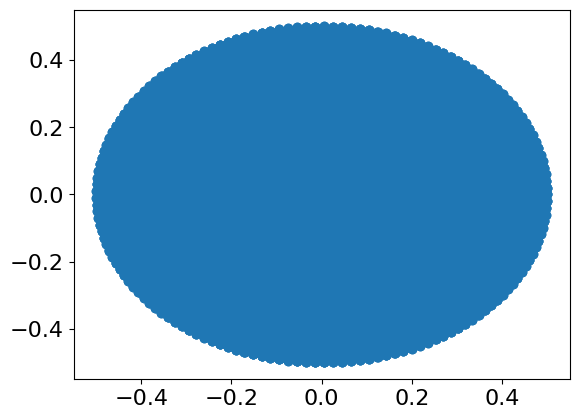

In [34]:
filled_sphere_points = generate_filled_sphere(radius=0.5, d=0.02)
plt.scatter(filled_sphere_points[:,0], filled_sphere_points[:,1])

<>:35: SyntaxWarning: invalid escape sequence '\A'
<>:35: SyntaxWarning: invalid escape sequence '\A'
C:\Users\htchi\AppData\Local\Temp\ipykernel_133764\1912334132.py:35: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)')


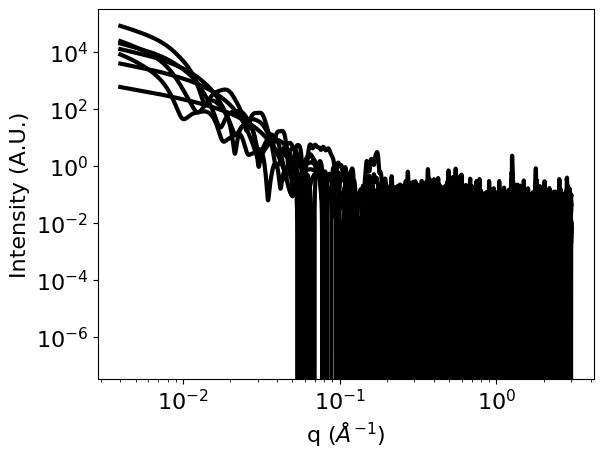

In [73]:
filled_sphere_points = generate_filled_sphere(radius=0.5, d=0.02)
f = -25
distribution_x = np.array([100+f, 150+f, 200+f, 250+f, 300+f, 350+f, 400+f])
distribution_y = np.array([0.05, 0.1, 0.2, 0.4, 0.20, 0.1, 0.05])

for i in range(len(distribution_x)):
    #plt.plot(distribution_x, distribution_y)
    # Example usage
    #plt.scatter(filled_sphere_points[:,0], filled_sphere_points[:,2])
    building_block = filled_sphere_points
    cylinder_points = generate_filled_cylinder_with_spacing(radius=distribution_x[i], height=1500, d=5)
    lattice_coordinates = cylinder_points
    n_random = 0
    random_displacement = (np.random.rand(lattice_coordinates.shape[0], 3) - 0.5)*n_random

    lattice_coordinates = lattice_coordinates + random_displacement
    #plt.scatter(cylinder_points[:,0], cylinder_points[:,1])

    n_samples = 10000000
    simulator = pairwise_method.scattering_simulator(n_samples)
    simulator.sample_building_block(building_block)
    simulator.sample_lattice_coordinates(lattice_coordinates)
    simulator.calculate_structure_coordinates()
    histogram_bins = 10000
    q = np.geomspace(0.004, 3, 6000)
    #I_q = simulator.simulate_multiple_scattering_curves_lattice_coords(building_block, lattice_coordinates, histogram_bins, q, save=False).numpy()
    I_q = simulator.simulate_scattering_curve_fast_lattice(building_block, lattice_coordinates, histogram_bins, q, save=False).reshape(-1,1)
    
    I_q = I_q/invariant(np.hstack((q.reshape(-1,1), I_q.reshape(-1,1))))
    I_q = I_q*distribution_y[i]
    plt.plot(q, I_q, linewidth = 3, label = 'MC-DFM', color='k')
    plt.yscale('log')
    plt.xscale('log')
    plt.ylabel('Intensity (A.U.)')
    plt.xlabel('q ($\AA^{-1}$)')
    if i == 0:
        I_q_all = I_q
    else:
        I_q_all = I_q_all + I_q
I_q = I_q_all

## Plot the Scattering Curve

<>:12: SyntaxWarning: invalid escape sequence '\A'
<>:12: SyntaxWarning: invalid escape sequence '\A'
C:\Users\htchi\AppData\Local\Temp\ipykernel_133764\895706433.py:12: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('q ($\AA^{-1}$)')


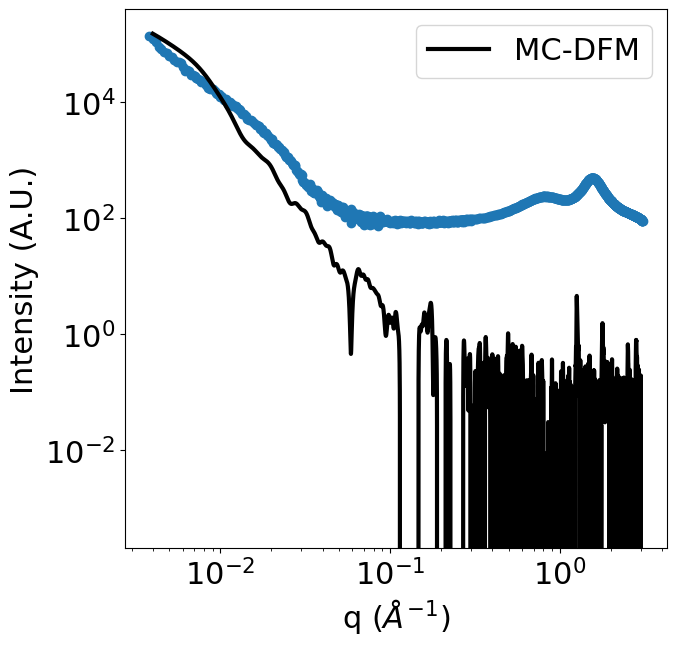

In [74]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7))
background = 0
#plt.plot(q, np.mean(I_q, axis=1) + background, linewidth = 3, label = 'MC-DFM', color='k')
#plt.plot(q, np.mean(I_q_long, axis=1) + background, linewidth = 3, label = 'length = 480nm', color='red')
data = pd.read_csv('../Data/scattering/zinc_oxide.csv').values
plt.plot(q, I_q + background, linewidth = 3, label = 'MC-DFM', color='k')
plt.scatter(data[:,0], data[:,1]*1e4)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Intensity (A.U.)')
plt.xlabel('q ($\AA^{-1}$)')
ax.minorticks_on()
plt.legend(loc=1)
#plt.show()
#plt.savefig('../Images/Single_tube.png', dpi=600, bbox_inches="tight")
#data = np.hstack((q.reshape(-1,1), np.mean(I_q, axis=1).reshape(-1,1)))
#np.save('../Data/simulated_scattering/RhuA_3/RhuA_' + str(amp) + '_amp_' + str(start) + '_start_' + str(OD) + 'nm_OD.npy', data)

## Plot the Pairwise Distribution

<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
C:\Users\htchi\AppData\Local\Temp\ipykernel_133764\1037985902.py:5: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Interatomic Distance ($\AA$)')


Text(0.5, 0, 'Interatomic Distance ($\\AA$)')

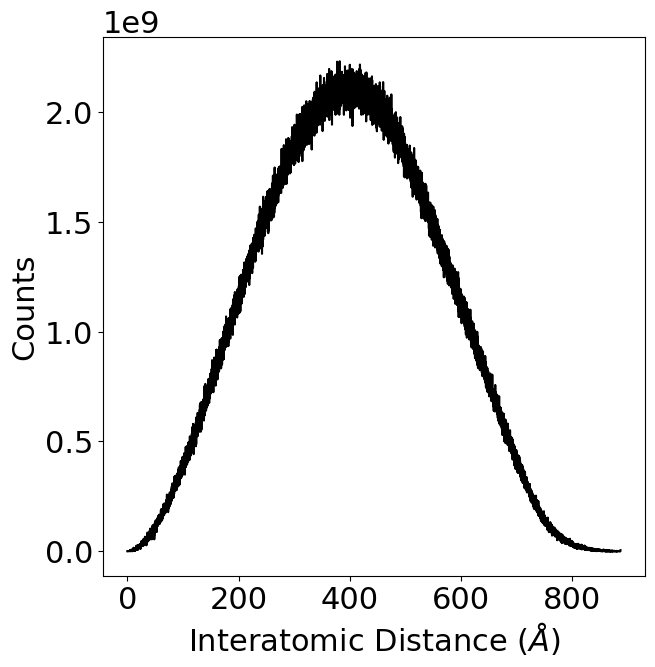

In [71]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7))
plt.plot(simulator.r, simulator.p_r*1e6, color='k')
plt.ylabel('Counts')
plt.xlabel('Interatomic Distance ($\AA$)')
#plt.savefig('../Images/RhuA/pairwise_dist_tubes.png', dpi=300, bbox_inches="tight")

To confirm which object the scattering curve belongs to, we can plot the randomly sampled coordiantes used to create the pairwise distribution. As expected, the object is the tube like structure made from assembling the RhuA protein. 

<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:8: SyntaxWarning: invalid escape sequence '\A'
<>:12: SyntaxWarning: invalid escape sequence '\A'
<>:13: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:8: SyntaxWarning: invalid escape sequence '\A'
<>:12: SyntaxWarning: invalid escape sequence '\A'
<>:13: SyntaxWarning: invalid escape sequence '\A'
C:\Users\htchi\AppData\Local\Temp\ipykernel_133764\2216629642.py:7: SyntaxWarning: invalid escape sequence '\A'
  ax[0].set_xlabel('x axis [$\AA$]')
C:\Users\htchi\AppData\Local\Temp\ipykernel_133764\2216629642.py:8: SyntaxWarning: invalid escape sequence '\A'
  ax[0].set_ylabel('y axis [$\AA$]')
C:\Users\htchi\AppData\Local\Temp\ipykernel_133764\2216629642.py:12: SyntaxWarning: invalid escape sequence '\A'
  ax[1].set_xlabel('x axis [$\AA$]')
C:\Users\htchi\AppData\Local\Temp\ipykernel_133764\2216629642.py:13: SyntaxWarning: invalid escape sequence '\A'
  ax[1].set_ylabel('z axis [$\AA$]'

Text(0, 0.5, 'z axis [$\\AA$]')

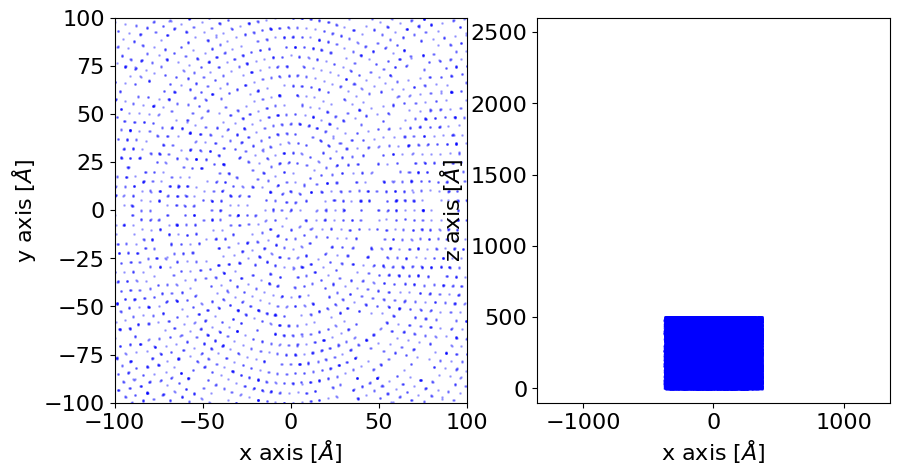

In [72]:
struc = simulator.structure_coordinates_1
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10,5), ncols=2, nrows=1)
ax[0].scatter(struc[:,0][::50], struc[:,1][::50], alpha = 0.25, s=1, color = 'blue')
ax[0].set_xlim([-100,100])
ax[0].set_ylim([-100,100])
ax[0].set_xlabel('x axis [$\AA$]')
ax[0].set_ylabel('y axis [$\AA$]')
ax[1].scatter(struc[:,0][::10], struc[:,2][::10], alpha = 0.25, s=1, color = 'blue')
ax[1].set_xlim([-1350,1350])
ax[1].set_ylim([-100,2600])
ax[1].set_xlabel('x axis [$\AA$]')
ax[1].set_ylabel('z axis [$\AA$]')

#plt.savefig('../Images/Sampled_Electron_Density_Tube_assembly_2.png', dpi=300, bbox_inches="tight")